# 第 6 章 · 图谱多跳推理代码实验

本页把人物、奖项、研究方向写成三元组图谱。读者要观察的不是普通 BFS，而是“每一跳关系是否符合查询意图”。

[章节网页](../ch6.html)

## 运行内容

- 准备 Wikidata 风格三元组
- 运行多跳查询
- 展示路径排序与结果图

## 0. 知识图谱

先看三元组表：头实体是起点，关系表示边的类型，尾实体是指向对象。多跳查询会沿着关系一层层展开。

In [1]:
# 载入本页会用到的数据表、队列和绘图工具。
import importlib.util
import logging
import subprocess
import sys
import warnings
from collections import defaultdict, deque
from pathlib import Path

required_packages = {
    "pandas": "pandas>=2.0",
    "matplotlib": "matplotlib>=3.7",
}
missing = [package for module, package in required_packages.items() if importlib.util.find_spec(module) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing])

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from IPython.display import display

font_paths = [
    "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc",
    "/usr/share/fonts/opentype/noto/NotoSansCJK-Bold.ttc",
    "/System/Library/Fonts/Supplemental/Arial Unicode.ttf",
    "/Library/Fonts/Arial Unicode.ttf",
    "/System/Library/Fonts/STHeiti Medium.ttc",
    "/System/Library/Fonts/STHeiti Light.ttc",
]
font_name = "DejaVu Sans"
for path in font_paths:
    if Path(path).exists():
        fm.fontManager.addfont(path)
        font_name = fm.FontProperties(fname=path).get_name()
        break

logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)
warnings.filterwarnings("ignore")
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.unicode_minus": False,
    "font.family": "sans-serif",
    "font.sans-serif": [font_name, "DejaVu Sans", "sans-serif"],
})

In [2]:
# 类 Wikidata 知识图谱：三元组表示为“头实体-关系-尾实体”。
triples = [
    ("玛丽·居里", "获得", "诺贝尔物理学奖"),
    ("玛丽·居里", "获得", "诺贝尔化学奖"),
    ("诺贝尔物理学奖", "类型", "诺贝尔奖"),
    ("诺贝尔化学奖", "类型", "诺贝尔奖"),
    ("玛丽·居里", "研究", "放射性"),
    ("放射性", "属于", "物理学"),
    ("物理学", "关联", "诺贝尔物理学奖"),
    ("玛丽·居里", "任职", "巴黎大学"),
    ("巴黎大学", "位于", "巴黎"),
    ("皮埃尔·居里", "合作", "玛丽·居里"),
]

start_entity = "玛丽·居里"
target_entity = "诺贝尔奖"

kg_df = pd.DataFrame(triples, columns=["头实体", "关系", "尾实体"])
display(kg_df)

,头实体,关系,尾实体
0,玛丽·居里,获得,诺贝尔物理学奖
1,玛丽·居里,获得,诺贝尔化学奖
2,诺贝尔物理学奖,类型,诺贝尔奖
3,诺贝尔化学奖,类型,诺贝尔奖
4,玛丽·居里,研究,放射性
5,放射性,属于,物理学
6,物理学,关联,诺贝尔物理学奖
7,玛丽·居里,任职,巴黎大学
8,巴黎大学,位于,巴黎
9,皮埃尔·居里,合作,玛丽·居里


In [3]:
# 把三元组转成邻接表，保留关系名称，便于输出可读路径。
kg_adj = defaultdict(list)
for head, relation, tail in triples:
    kg_adj[head].append((tail, relation))

out_edges = pd.DataFrame(
    [
        {"实体": start_entity, "关系": relation, "指向": tail}
        for tail, relation in kg_adj[start_entity]
    ]
)
display(out_edges)

,实体,关系,指向
0,玛丽·居里,获得,诺贝尔物理学奖
1,玛丽·居里,获得,诺贝尔化学奖
2,玛丽·居里,研究,放射性
3,玛丽·居里,任职,巴黎大学


## 1. 多跳查询

查询过程会记录边界队列和新增路径。读者重点看路径是如何从起点实体一步步抵达目标实体的。

In [4]:
# 多跳查询：用队列逐层展开，记录每一步边界队列和新路径。
def find_paths(start, target, kg_adj, max_hops=3):
    queue = deque([(start, [])])
    rows = []
    paths = []
    step = 0

    while queue:
        step += 1
        entity, path = queue.popleft()
        frontier_before = [item[0] for item in queue]

        if len(path) >= max_hops:
            rows.append({
                "步骤": step,
                "展开实体": entity,
                "边界队列": "、".join(frontier_before) or "空",
                "新增路径": "达到跳数上限",
            })
            continue

        new_items = []
        for nxt, relation in kg_adj.get(entity, []):
            if any(edge["tail"] == nxt for edge in path):
                continue
            new_path = path + [{"head": entity, "relation": relation, "tail": nxt}]
            new_items.append(f"{entity}-{relation}->{nxt}")
            if nxt == target:
                paths.append(new_path)
            else:
                queue.append((nxt, new_path))

        rows.append({
            "步骤": step,
            "展开实体": entity,
            "边界队列": "、".join(frontier_before) or "空",
            "新增路径": "；".join(new_items) or "无",
        })

    return paths, pd.DataFrame(rows)


paths, graph_trace = find_paths(start_entity, target_entity, kg_adj, max_hops=3)
display(graph_trace)

,步骤,展开实体,边界队列,新增路径
0,1,玛丽·居里,空,玛丽·居里-获得->诺贝尔物理学奖；玛丽·居里-获得->诺贝尔化学奖；玛丽·居里-研究->放...
1,2,诺贝尔物理学奖,诺贝尔化学奖、放射性、巴黎大学,诺贝尔物理学奖-类型->诺贝尔奖
2,3,诺贝尔化学奖,放射性、巴黎大学,诺贝尔化学奖-类型->诺贝尔奖
3,4,放射性,巴黎大学,放射性-属于->物理学
4,5,巴黎大学,物理学,巴黎大学-位于->巴黎
5,6,物理学,巴黎,物理学-关联->诺贝尔物理学奖
6,7,巴黎,诺贝尔物理学奖,无
7,8,诺贝尔物理学奖,空,达到跳数上限


## 2. 路径排序

同一个目标可能有多条路径。这里把短路径和语义更贴近的关系排在前面，帮助读者理解为什么要给路径排序。

In [5]:
# 路径排序：更短路径优先；与目标语义更近的关系获得轻微加分。
def path_to_text(path):
    if not path:
        return ""
    pieces = [path[0]["head"]]
    for edge in path:
        pieces.append(f"-{edge['relation']}->")
        pieces.append(edge["tail"])
    return "".join(pieces)


def rank_paths(paths):
    rows = []
    for path_id, path in enumerate(paths):
        hop_count = len(path)
        relation_bonus = sum(1 for edge in path if edge["relation"] in {"获得", "类型", "关联"})
        score = 1 / hop_count + 0.08 * relation_bonus
        rows.append({
            "路径编号": path_id,
            "路径": path_to_text(path),
            "跳数": hop_count,
            "关系加分": round(0.08 * relation_bonus, 2),
            "排序分": round(score, 3),
        })
    return pd.DataFrame(rows).sort_values("排序分", ascending=False).reset_index(drop=True)


ranked_paths = rank_paths(paths)
display(ranked_paths)

,路径编号,路径,跳数,关系加分,排序分
0,0,玛丽·居里-获得->诺贝尔物理学奖-类型->诺贝尔奖,2,0.16,0.66
1,1,玛丽·居里-获得->诺贝尔化学奖-类型->诺贝尔奖,2,0.16,0.66


## 3. 结果图

最后只高亮最高分路径，避免整张图太拥挤。读者可以把它当作“多跳推理的证据链”。

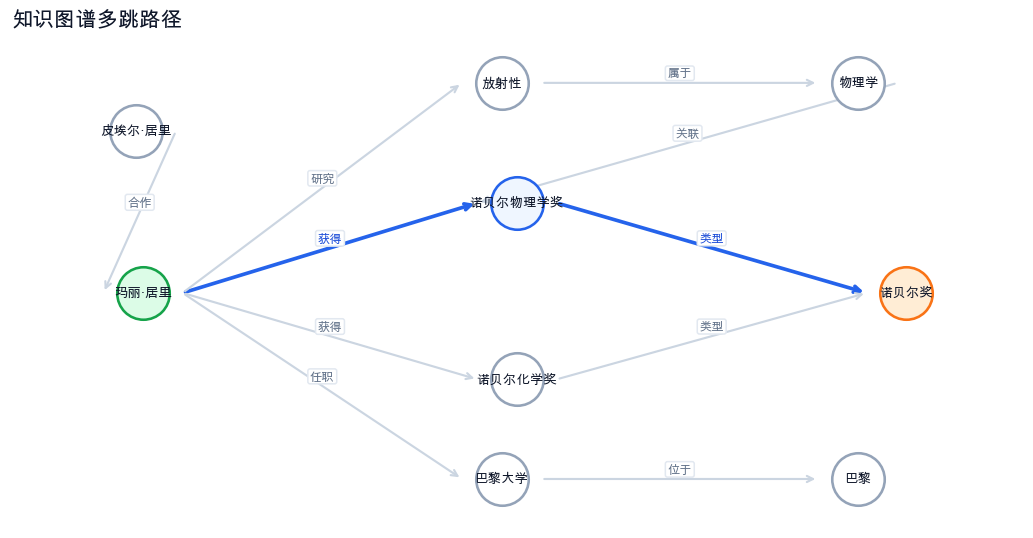

In [6]:
# 绘制最高分路径：突出多跳推理经过的实体和关系。
def draw_kg_path(triples, best_path):
    nodes = sorted(set([h for h, _, _ in triples] + [t for _, _, t in triples]))
    layout = {
        "玛丽·居里": (0.25, 1.5),
        "诺贝尔物理学奖": (1.95, 2.25),
        "诺贝尔化学奖": (1.95, 0.78),
        "诺贝尔奖": (3.72, 1.5),
        "放射性": (1.88, 3.25),
        "物理学": (3.50, 3.25),
        "巴黎大学": (1.88, -0.05),
        "巴黎": (3.50, -0.05),
        "皮埃尔·居里": (0.22, 2.85),
    }
    active = {(edge["head"], edge["relation"], edge["tail"]) for edge in best_path}
    active_nodes = {edge["head"] for edge in best_path} | {edge["tail"] for edge in best_path}

    fig, ax = plt.subplots(figsize=(9.5, 5.0))
    ax.set_facecolor("#fbfcfd")
    for head, relation, tail in triples:
        x1, y1 = layout[head]
        x2, y2 = layout[tail]
        is_active = (head, relation, tail) in active
        ax.annotate(
            "",
            xy=(x2 - 0.18, y2),
            xytext=(x1 + 0.18, y1),
            arrowprops={
                "arrowstyle": "->",
                "color": "#2563eb" if is_active else "#cbd5e1",
                "lw": 2.4 if is_active else 1.4,
            },
            zorder=1,
        )
        ax.text(
            (x1 + x2) / 2,
            (y1 + y2) / 2 + 0.08,
            relation,
            ha="center",
            va="center",
            fontsize=8,
            color="#1d4ed8" if is_active else "#64748b",
            bbox={"boxstyle": "round,pad=0.18", "fc": "white", "ec": "#e2e8f0"},
            zorder=2,
        )

    for node in nodes:
        x, y = layout[node]
        is_active = node in active_nodes
        face = "#eff6ff" if is_active else "#ffffff"
        edge = "#2563eb" if is_active else "#94a3b8"
        if node == start_entity:
            face, edge = "#dcfce7", "#16a34a"
        if node == target_entity:
            face, edge = "#ffedd5", "#f97316"
        ax.scatter(x, y, s=1180, color=face, edgecolor=edge, linewidth=1.7, zorder=3)
        ax.text(x, y, node, ha="center", va="center", fontsize=8.8, fontweight="bold", color="#0f172a", zorder=4)

    ax.set_title("知识图谱多跳路径", loc="left", fontsize=14, fontweight="bold", color="#0f172a")
    ax.set_xlim(-0.35, 4.25)
    ax.set_ylim(-0.45, 3.65)
    ax.axis("off")
    plt.tight_layout()
    plt.show()


best_path = paths[int(ranked_paths.loc[0, "路径编号"])]
draw_kg_path(triples, best_path)